In [13]:
#!pip install scipy numpy sympy matplotlib pandas

In [14]:

from scipy.signal import savgol_filter
import sympy as sp
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline
from IPython.display import display, Markdown

def make_smooth_K(lam_data, k_values, window=51, poly=3, spline_smooth=1e-4):
    """
    Returns a smoothed callable K(lambda).

    Parameters
    ----------
    lam_data : 1-D array  - affine parameter samples from DATA_CARTER.dat
    k_values : 1-D array  – Carter constant samples
    window   : int        – Savitzky-Golay window length (must be odd, > poly)
    poly     : int        – SG polynomial order
    spline_smooth : float – UnivariateSpline smoothing factor for the residual
    """
    window = window if window % 2 == 1 else window + 1
    k_sg   = savgol_filter(k_values, window_length=window, polyorder=poly)
    return UnivariateSpline(lam_data, k_sg, s=spline_smooth, ext='const')

data_k = np.loadtxt('DATA_CARTER.dat')
lam_data = data_k[:, 0]
k_values = data_k[:, 1]
get_K = make_smooth_K(lam_data, k_values, window=51, poly=3)

r, theta, E, Lz, a, epsilon, kappa = sp.symbols('r theta E L_z a epsilon kappa')
M = 1.0

Delta_s, Sigma_s, H1_s, H2_s = sp.symbols('Delta Sigma H_1 H_2')

Delta_math = r**2 - 2*M*r + a**2
Sigma_math = r**2 + a**2 * sp.cos(theta)**2
H1_math = epsilon * (Lz - 2*a*E)
H2_math = (epsilon**2 / (8*Sigma_s)) * (-4*a**2 * Delta_s + (5*a**4 + r**4 +2*a**2 *r**2 - 8*M*a**2*r)*sp.sin(theta)**2 - a**2*Delta_s*sp.sin(theta)**4)

#Shorthand symbols for display
V1_disp = (E*(r**2 + a**2) - a*Lz)**2 - Delta_s * (kappa + r**2) + Delta_s * r**2 * H1_s - 2*Delta_s * r**2 * H2_s
V2_disp = (1/sp.sin(theta)**2)*((kappa - (Lz - a*E)**2)*sp.sin(theta)**2 - (Lz*sp.cos(theta))**2 + (a*E*sp.cos(theta)*sp.sin(theta))**2 - (a*sp.cos(theta)*sp.sin(theta))**2 - (a*sp.cos(theta)*sp.sin(theta))**2 * H1_s - 2*(a*sp.cos(theta)*sp.sin(theta))**2 * H2_s)

#Substitute expressions
H2_full = H2_math.subs({Delta_s: Delta_math, Sigma_s: Sigma_math})
V1_full = V1_disp.subs({Delta_s: Delta_math, H1_s: H1_math, H2_s: H2_full})
V2_full = V2_disp.subs({H1_s: H1_math, H2_s: H2_full})

#Full function for numerical use
rhs_potentials = sp.lambdify((r, theta, E, Lz, a, kappa, epsilon), [V1_full, V2_full], 'numpy')



display(Markdown("### Symbolic Definitions"))
display_list = [
    ("V_1", V1_disp),
    ("V_2", V2_disp),
    ("H_1", H1_math),
    ("H_2", H2_math),
    ("\\Delta", Delta_math),
    ("\\Sigma", Sigma_math)
]

size_command = r"\Large" 

for label, expr in display_list:
    eq = sp.Eq(sp.Symbol(label), expr)
    
    latex_str = sp.latex(eq)
    
    display(Markdown(f"$${size_command} {latex_str}$$"))
    


### Symbolic Definitions

$$\Large V_{1} = \Delta H_{1} r^{2} - 2 \Delta H_{2} r^{2} - \Delta \left(\kappa + r^{2}\right) + \left(E \left(a^{2} + r^{2}\right) - L_{z} a\right)^{2}$$

$$\Large V_{2} = \frac{E^{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - H_{1} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - 2 H_{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - L_{z}^{2} \cos^{2}{\left(\theta \right)} - a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + \left(\kappa - \left(- E a + L_{z}\right)^{2}\right) \sin^{2}{\left(\theta \right)}}{\sin^{2}{\left(\theta \right)}}$$

$$\Large H_{1} = \epsilon \left(- 2 E a + L_{z}\right)$$

$$\Large H_{2} = \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(5 a^{4} + 2 a^{2} r^{2} - 8.0 a^{2} r + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{8 \Sigma}$$

$$\Large \Delta = a^{2} + r^{2} - 2.0 r$$

$$\Large \Sigma = a^{2} \cos^{2}{\left(\theta \right)} + r^{2}$$

In [15]:
E, Lz, a, epsilon = 0.98, 3.3, 0.5, -0.001
lam, r, theta = 2.642455 , 40.324777000000000,	1.5722110000000000
test_state = (r, theta, E, Lz, a, get_K(lam), epsilon)
v1 = rhs_potentials(*test_state)[0]
print(v1)

0.5362565643154085


In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def geodesic_integrator(initial_state, initial_signs, lam_range, params, epsilon, proxy_eps):
    E_val, Lz_val, a_val = params
    eps_val = epsilon
    curr_lam, end_lam = lam_range
    curr_state = np.array(initial_state, dtype=float)

    def odes(t, y, E_v, Lz_v, a_v, eps_v):
        r_c, th_c = y
        k_c = get_K(t)
        v1, v2 = rhs_potentials(r_c, th_c, E_v, Lz_v, a_v, k_c, eps_v)
        
        # Using abs ensures the solver doesn't crash, 
        # but the rejector will catch if it "glides" in the wrong region.
        dr = np.sqrt(max(v1, proxy_eps)) * odes.sign_r
        dt = np.sqrt(max(v2, proxy_eps)) * odes.sign_th
        return [dr, dt]

    odes.sign_r, odes.sign_th = initial_signs

    def event_v1(t, y, *args):
        v1, _ = rhs_potentials(y[0], y[1], *args[:3], get_K(t), args[3])
        return v1 - proxy_eps
    event_v1.terminal, event_v1.direction = True, -1

    def event_v2(t, y, *args):
        _, v2 = rhs_potentials(y[0], y[1], *args[:3], get_K(t), args[3])
        return v2 - proxy_eps
    event_v2.terminal, event_v2.direction = True, -1

    def event_horizon(t, y, *args): return y[0] - 2.001
    event_horizon.terminal = True

    def event_r_max(t, y, *args): return y[0] - 100.0
    event_r_max.terminal = True

    def event_theta_bounds(t, y, *args):
        return (y[1] - 0.001) * (np.pi - 0.001 - y[1])
    event_theta_bounds.terminal = True

    all_r, all_th, all_l = [], [], []
    loop_log = []

    while curr_lam < end_lam:
        sol = solve_ivp(
            odes, (curr_lam, end_lam), curr_state,
            args=(E_val, Lz_val, a_val, eps_val),
            events=[event_v1, event_v2, event_horizon, event_r_max, event_theta_bounds],
            rtol=1e-5, atol=1e-10, method='RK45', dense_output=True
        )  

        # Aggregate valid results
        if not all_l:
            all_r.extend(sol.y[0])
            all_th.extend(sol.y[1])
            all_l.extend(sol.t)
        else:
            all_r.extend(sol.y[0, 1:])
            all_th.extend(sol.y[1, 1:])
            all_l.extend(sol.t[1:])
        
        curr_state = sol.y[:, -1]
        curr_lam = sol.t[-1]

        loop_log.append({
            'lambda': curr_lam,
            'state': curr_state.tolist(),
            'events': [len(e) for e in sol.t_events],
            'success': sol.success,
            'message': sol.message
        })

        # Logic for normal event-driven terminations
        if sol.t_events[2].size > 0:
            print(f"Halt: Horizon reached at lambda={curr_lam:.2f}")
            break
        if sol.t_events[3].size > 0 or sol.t_events[4].size > 0:
            print(f"Halt: Boundary reached at lambda={curr_lam:.2f}")
            break

        # Normal momentum sign flip and small nudge at detected turning points
        if sol.t_events[0].size > 0:
            odes.sign_r *= -1
            curr_state[0] += odes.sign_r * 1e-5
            curr_lam += np.abs((all_l[-1] - all_l[-2])/(all_r[-1] - all_r[-2]))*1e-5
        if sol.t_events[1].size > 0:
            odes.sign_th *= -1
            curr_state[1] += odes.sign_th * 1e-5
            curr_lam += np.abs((all_l[-1] - all_l[-2])/(all_th[-1] - all_th[-2]))*1e-5

    return {
        'r': np.array(all_r),
        'theta': np.array(all_th),
        'lambda': np.array(all_l),
        'log': pd.DataFrame(loop_log)
    }

In [125]:
#Config and exec
init_state = [40.323, np.pi/2]
phys_params = (0.98, 3.3, 0.5)
eps = -0.001

results = geodesic_integrator(
    init_state,
    initial_signs=[-1, -1],
    lam_range=[0, 40],
    params=phys_params,
    epsilon=eps,
    proxy_eps=0
)

In [126]:
# Data Processing 
results['log'].to_csv("loop_log.csv", index=False)


tol = 1e-14
diffs = np.diff(results['lambda'])

mask = np.append(diffs > tol, [True])

#print(mask)

lam_clean = results['lambda'][mask]
r_clean = results['r'][mask]
th_clean = results['theta'][mask]

# vr = dr/dlam (Just the derivative)
vr = np.gradient(r_clean, lam_clean)
vth = np.gradient(th_clean, lam_clean)

#Recalculate V1, V2
v1_vals, v2_vals = rhs_potentials(
    results['r'], 
    results['theta'], 
    phys_params[0], 
    phys_params[1], 
    phys_params[2], 
    get_K(results['lambda']), 
    epsilon
)

df = pd.DataFrame({
    'lambda': lam_clean,
    'r': r_clean,
    'theta': th_clean,
    'V1': v1_vals,
    'V2': v2_vals,
    'vr': vr,
    'vth': vth
})

df.to_csv('data.csv', index=False)

Text(0.5, 0, 'Mino Time, $\\lambda$')

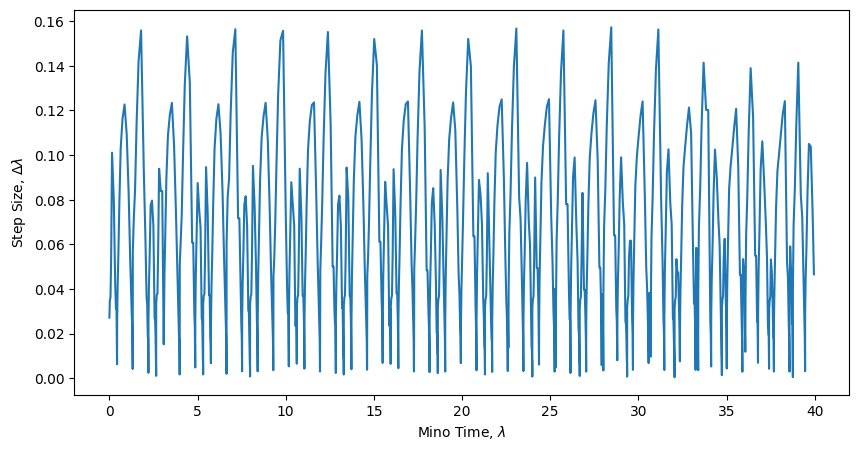

In [127]:
delta_lam = []
for i in range(1, len(results['lambda'])):
    delta_lam.append(results['lambda'][i] - results['lambda'][i-1])

plt.figure(figsize=(10, 5))    
plt.plot(results['lambda'][:-1], delta_lam)
plt.ylabel(r'Step Size, $\Delta\lambda$')
plt.xlabel(r'Mino Time, $\lambda$')

9.473408316666172
184.15732978229804


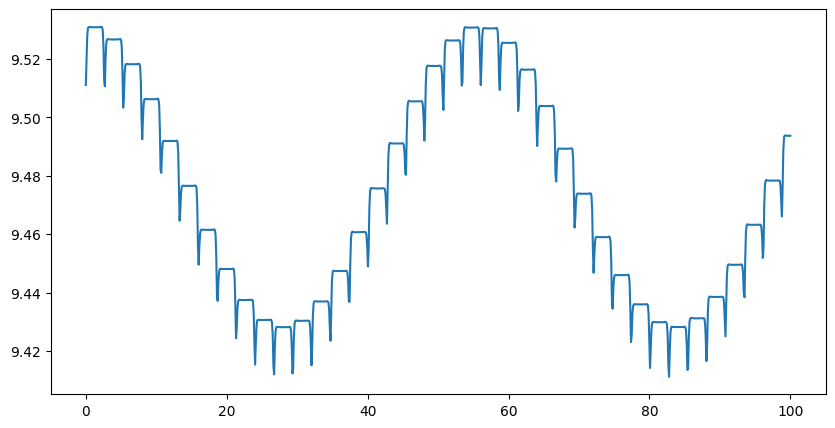

In [128]:
lams = np.linspace(0, 100, 1000)
K = get_K((lams))
plt.figure(figsize=(10,5))
plt.plot(lams, K)

print(np.mean(K))

print(lam_data[-1])

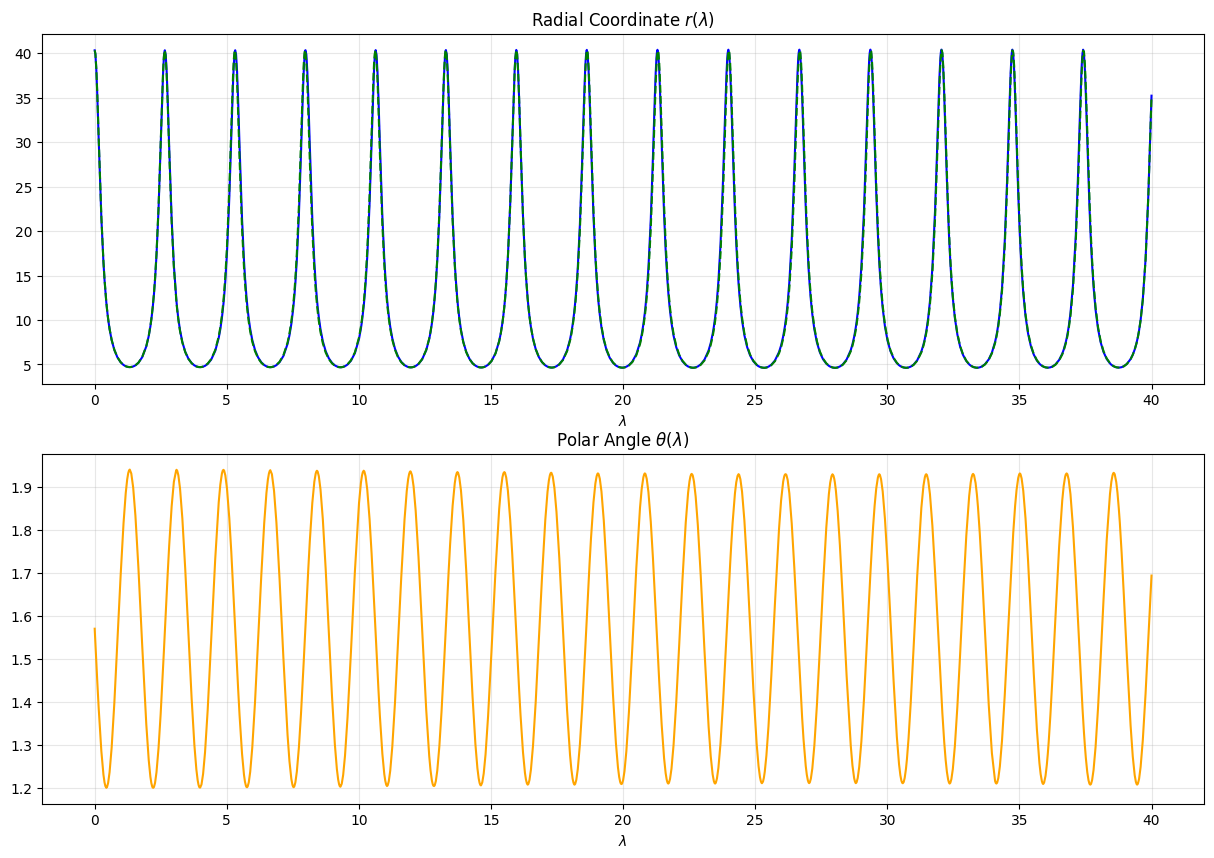

Mean Error =  0.015387556722429977
Max Error =  0.06113447898091977


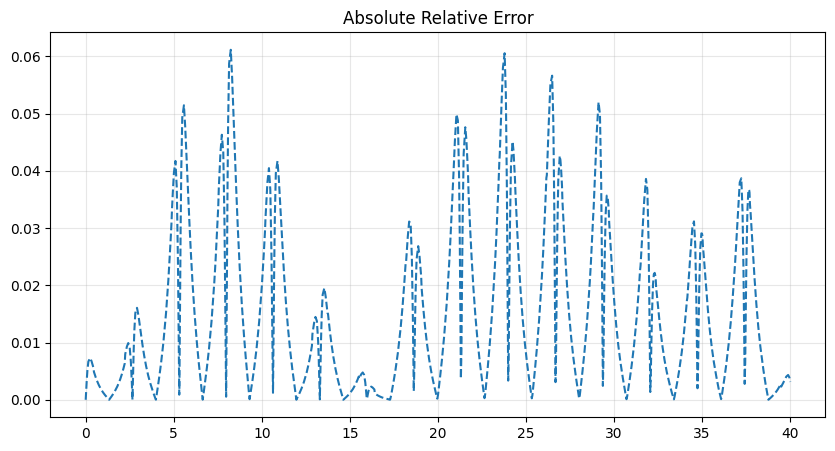

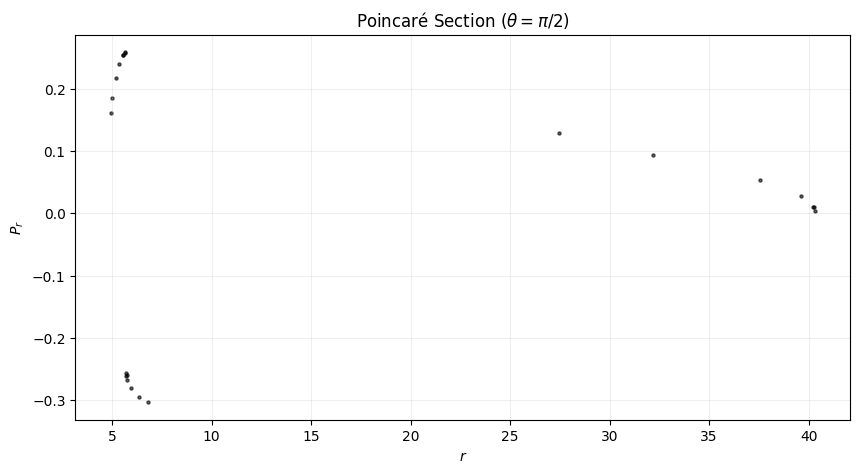

In [129]:
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

r_arr = df['r']
Delta = r_arr**2 - 2*r_arr + a**2
#Sigma = r_arr**2 + a**2 * np.cos(th_arr)**2
th_arr = df['theta']
lam_arr = df['lambda']
vth_arr = df['vth']
pth_arr = vth_arr
pr_arr = (1/Delta)*df['vr']

data_r = np.loadtxt('Neal.dat')
lam_data = data_r[:, 0]
r_values = data_r[:, 1]
get_R = CubicSpline(lam_data, r_values)
#vr_arr = np.sqrt(np.maximum(0, v1_vals))

r_interp = get_R(lam_arr)
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.plot(lam_arr, r_arr, color='blue')
ax1.plot(lam_arr, r_interp, color='green', linestyle='--')
ax1.set_title(r"Radial Coordinate $r(\lambda)$")
ax1.set_xlabel(r"$\lambda$")
ax1.grid(True, alpha=0.3)
#ax1.set_xlim(0, 5)

ax2.plot(lam_arr, th_arr, color='orange')
ax2.set_title(r"Polar Angle $\theta(\lambda)$")
ax2.set_xlabel(r"$\lambda$")
ax2.grid(True, alpha=0.3)
plt.show()

error = np.abs(r_interp - r_arr)/r_arr

plt.figure(figsize=(10, 5))
plt.plot(lam_arr, error, linestyle = '--')
plt.title(r"Absolute Relative Error")
#plt.yscale('log')
plt.grid(True, alpha=0.3)
print(f"Mean Error = ", np.mean(error))
print(f"Max Error = ", np.max(error))

import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline

def get_precise_crossings(lam_arr, th_arr, r_arr, pr_arr, target_th=np.pi/2):
    """
    Finds exact crossings by finding roots of the function 
    f(lambda) = theta(lambda) - pi/2.
    """
    # 1. We must clean duplicate timestamps first
    mask = np.concatenate(([True], np.diff(lam_arr) > 1e-13))
    t_c, th_c, r_c, pr_c = lam_arr[mask], th_arr[mask], r_arr[mask], pr_arr[mask]

    # 2. Cubic splines provide a smooth th(lam) and th'(lam)
    th_spline = CubicSpline(t_c, th_c)
    r_spline = CubicSpline(t_c, r_c)
    pr_spline = CubicSpline(t_c, pr_c) # If pr is canonical
    dth_spline = th_spline.derivative()

    p_r_exact = []
    p_pr_exact = []
    p_lam_exact = []
    
    # 3. Iterate through intervals where crossings occurred
    for i in range(len(t_c) - 1):
        if (target_th - th_c[i]) * (target_th - th_c[i+1]) < 0:
            
            # Root-finder calculates the exact lambda_cross on the smooth spline
            # f(t) = target_th - spline(t)
            lam_cross = brentq(lambda t: target_th - th_spline(t), t_c[i], t_c[i+1])

            # 4. We only keep the crossing in one direction (descending node)
            if dth_spline(lam_cross) < 0:
                p_r_exact.append(r_spline(lam_cross))
                p_pr_exact.append(pr_spline(lam_cross))
                p_lam_exact.append(lam_cross)
                
    return np.array(p_r_exact), np.array(p_pr_exact), np.array(p_lam_exact)

p_r, p_pr, p_lam = get_precise_crossings(lam_arr, th_arr, r_arr, pr_arr)

'''def get_poincare_data(th_vals, r_vals, vr_vals, t_vals): #Old Poincare Calculations (Double the points, scrapped)
    poincare_r = []
    poincare_vr = []
    poincare_time = []
    
    # Define the crossing value
    plane = np.pi / 2
    
    # Find indices where theta crosses the plane
    crossings = np.where(np.diff(np.sign(th_vals - plane)))[0]
    
    for idx in crossings:   
        # Simple linear interpolation for better precision at the crossing
        # Between index idx and idx+1
        poincare_r.append(r_vals[idx])
        poincare_vr.append(vr_vals[idx]/Delta(r_vals[idx]))
        poincare_time.append(t_vals[idx])
        
    return np.array(poincare_r), np.array(poincare_vr), np.array(poincare_time)'''

plt.figure(figsize=(10, 5))
plt.scatter(p_r, p_pr, s=5, color='black', alpha=0.6)
plt.title(r"Poincaré Section ($\theta = \pi/2$)")
plt.xlabel(r"$r$")
plt.ylabel(r"$P_r$")
plt.grid(True, alpha=0.2)
plt.show()


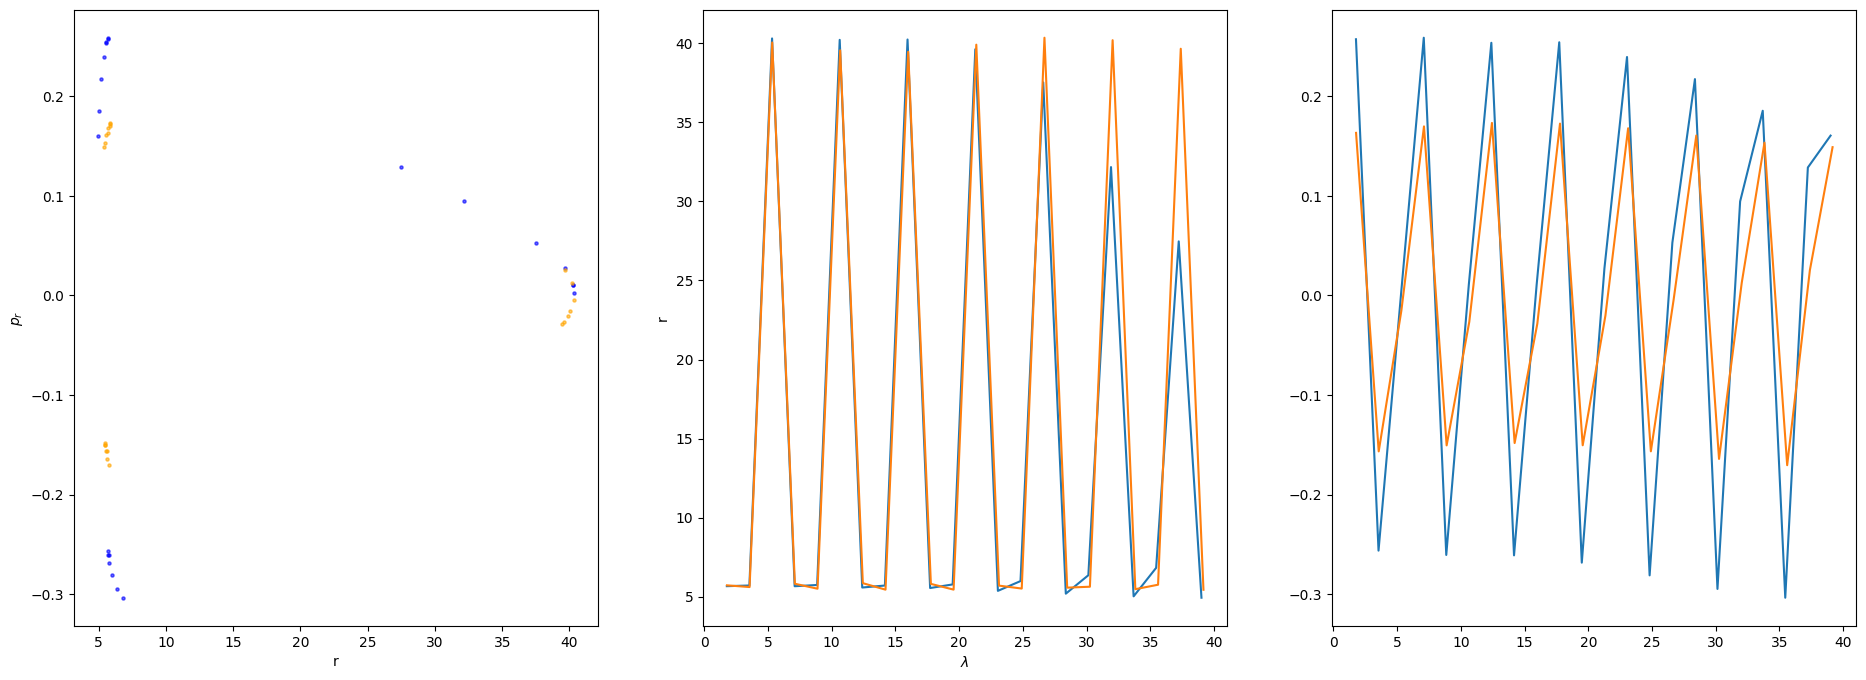

In [130]:
data_pcr = np.loadtxt("Poincare_Mino.dat")
mask = data_pcr[:, 0] <= 40
pr_lam = data_pcr[:, 0][mask]
pr_r = data_pcr[:, 1][mask]
pr_pr = data_pcr[:, 2][mask]

i = 0
n = 1

pr_sliced = p_r[i::n]
p_pr_sliced = p_pr[i::n]
plam_sliced = p_lam[i::n]

j = i
pr_lam_s = pr_lam[j::n]
pr_r_s = pr_r[j::n]
pr_p_s = pr_pr[j::n]

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(23, 8))
ax1.scatter(pr_sliced, p_pr_sliced, s=5, alpha=0.6, color='blue')
ax1.scatter(pr_r_s, pr_p_s, s=5, alpha=0.6, color='orange')
ax1.set_xlabel('r')
ax1.set_ylabel(r'$p_r$')

ax2.plot(plam_sliced, pr_sliced)
ax2.plot(pr_lam_s, pr_r_s)
ax2.set_xlabel(r'$\lambda$')
ax2.set_ylabel('r')


ax3.plot(plam_sliced, p_pr_sliced)
ax3.plot(pr_lam_s, pr_p_s)

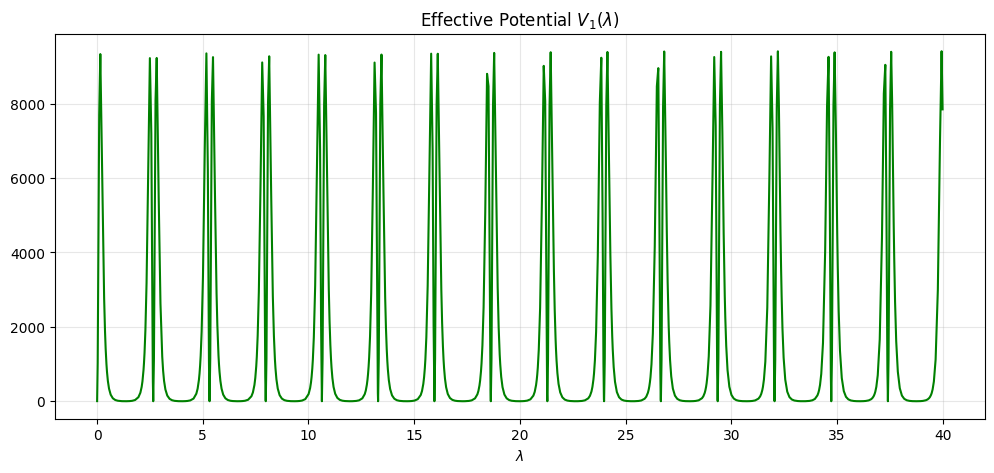

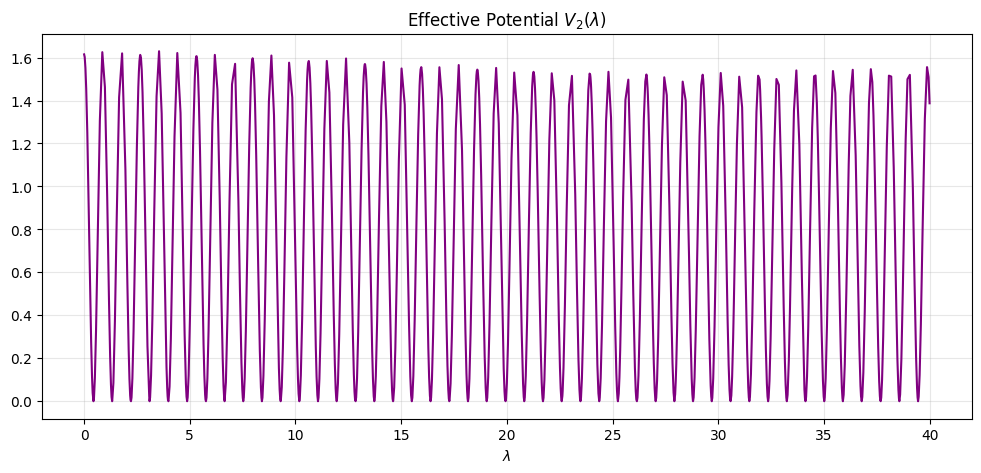

In [131]:
#Recomputing V1 and V2 from solved r and theta
V1_vals = np.array([rhs_potentials(r, th, E, Lz, a, get_K(lam), epsilon)[0] for r, th, lam in zip(r_arr, th_arr, lam_arr)])
V2_vals = np.array([rhs_potentials(r, th, E, Lz, a, get_K(lam), epsilon)[1] for r, th, lam in zip(r_arr, th_arr, lam_arr)])

plt.figure(figsize=(12, 5))
plt.plot(lam_arr, V1_vals, color='green')
plt.title(r"Effective Potential $V_1(\lambda)$")
plt.xlabel(r"$\lambda$")    
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(lam_arr, V2_vals, color='purple')  
plt.title(r"Effective Potential $V_2(\lambda)$")
plt.xlabel(r"$\lambda$")
plt.grid(True, alpha=0.3)
plt.show()



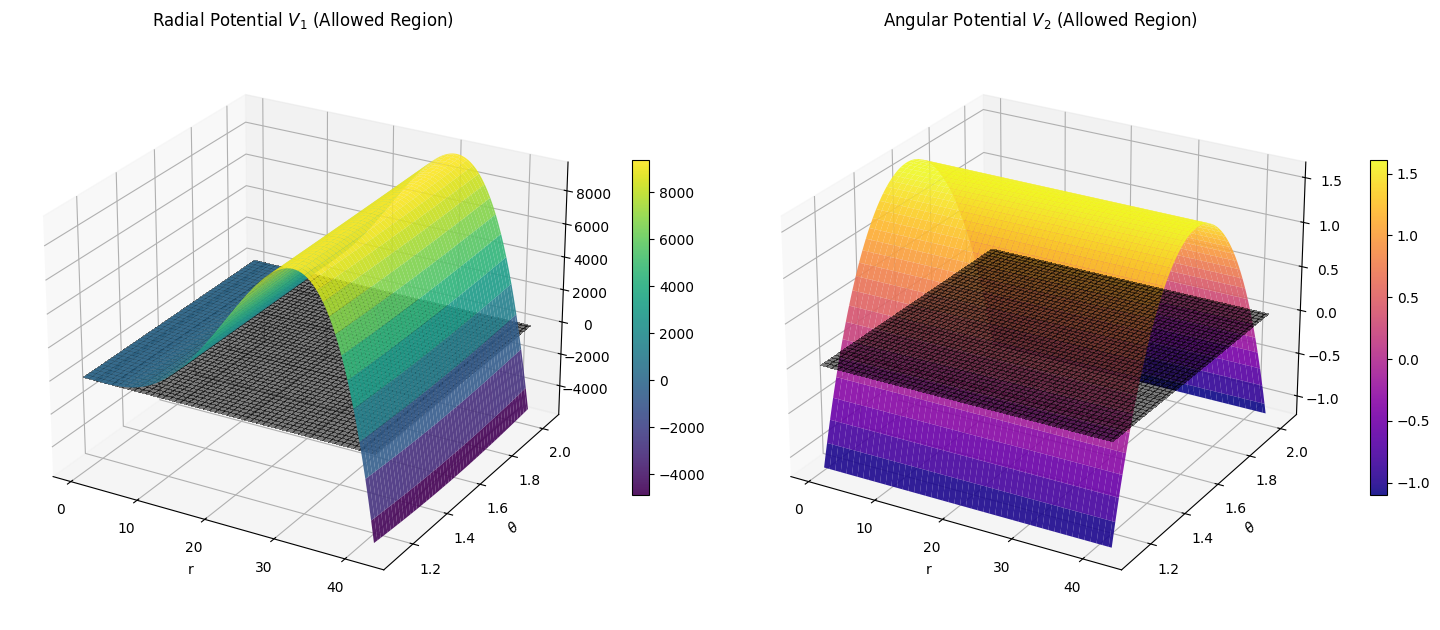

Roots:
r: [2.3407844987379764, 4.687730006739218, 40.32411036004529]
 theta: [1.2033318072124721, 1.9382608463773212]
V1 at r_initial = 40.323: 2.619413841050118


In [132]:
#V1 and V2 surface plots and roots
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def v1_root_func(r_val):
    v1, _ = rhs_potentials(r_val, np.pi/2, E, Lz, a, get_K(lam_data[0]), epsilon)
    return v1

# For V2, we find roots in 'theta' at a fixed r (e.g., current r)
def v2_root_func(th_val):
    _, v2 = rhs_potentials(r_arr[0], th_val, E, Lz, a, get_K(lam_data[0]), epsilon)
    return v2

def find_all_roots(func, start, end, pts=500):
    x = np.linspace(start, end, pts)
    # Use list comprehension to handle potential array/scalar issues from lambdify
    y = [func(xi) for xi in x]
    roots = []
    for i in range(len(x)-1):
        if y[i] * y[i+1] < 0:
            roots.append(brentq(func, x[i], x[i+1]))
    return roots

# 3. Calculate the roots
# Radial search from horizon to a safe upper bound
r_roots = find_all_roots(v1_root_func, 2.01, 100)
# Angular search from pole to pole
th_roots = find_all_roots(v2_root_func, 0.01, np.pi - 0.01)

Delta_r = 2.0
Delta_th = 0.1
if len(r_roots) >= 2 and len(th_roots) >= 2:
    # Use the min/max found roots to define the plot domain
    r_min, r_max = min(r_roots) - Delta_r, max(r_roots) + Delta_r
    th_min, th_max = min(th_roots) - Delta_th, max(th_roots) + Delta_th
    
    # 4. Create the confined grid
    r_grid = np.linspace(r_min, r_max, 100)
    th_grid = np.linspace(th_min, th_max, 100)
    R, TH = np.meshgrid(r_grid, th_grid)
    
    V1_grid, V2_grid = rhs_potentials(R, TH, E, Lz, a, get_K(lam_data[0]), epsilon)
        

    # 5. Plotting
    fig = plt.figure(figsize=(15, 7))
    
    # V1 Plot
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.view_init(elev=25, azim=-60)
    surf1 = ax1.plot_surface(R, TH, V1_grid, cmap='viridis', edgecolor='none', alpha=0.9)
    ax1.plot_surface(R, TH, np.zeros_like(R), cmap='gray', edgecolor='none', alpha=0.5, antialiased=False)  
    ax1.set_title(r'Radial Potential $V_1$ (Allowed Region)')
    ax1.set_xlabel('r'); ax1.set_ylabel(r'$\theta$')
    fig.colorbar(surf1, ax=ax1, shrink=0.5)
    ax1.contour(R, TH, V1_grid, levels=[0], colors='black', linestyles='dashed')
    # V2 Plot
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.view_init(elev=25, azim=-60)
    surf2 = ax2.plot_surface(R, TH, V2_grid, cmap='plasma', edgecolor='none', alpha=0.9)
    ax2.plot_surface(R, TH, np.zeros_like(R), cmap='gray', edgecolor='none', alpha=0.5, antialiased=False)  
    ax2.set_title(r'Angular Potential $V_2$ (Allowed Region)')
    ax2.set_xlabel('r'); ax2.set_ylabel(r'$\theta$')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)
    ax2.contour(R, TH, V2_grid, levels=[0], colors='black', linestyles='dashed')

    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find sufficient roots. r_roots: {r_roots}, th_roots: {th_roots}")
    
print(f"Roots:\nr: {r_roots}\n theta: {th_roots}")

r_initial = 40.323
print(f"V1 at r_initial = {r_initial:.3f}: {rhs_potentials(r_initial, np.pi/2, E, Lz, a, get_K(lam_data[0]), epsilon)[0]}")